In [1]:
!pip install kneed
# for elbow method

In [2]:
pip install gdown

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [4]:
# Download dataset
!gdown 16w9m7CK-vsTZrvw3XMROdkWLiasOxw68

Downloading...
From: https://drive.google.com/uc?id=16w9m7CK-vsTZrvw3XMROdkWLiasOxw68
To: /Users/juberry/Documents/Code/Machine-Learning/Machine Learning/Unsupervised_Learning/Classification/K-Means/Mall_Customers.csv
100%|█████████████████████████████████████| 4.29k/4.29k [00:00<00:00, 15.0MB/s]


In [5]:
df = pd.read_csv("/Users/juberry/Documents/Code/Machine-Learning/Data/KNN/Mall_Customers.csv")
df.drop("CustomerID", axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Genre                   200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


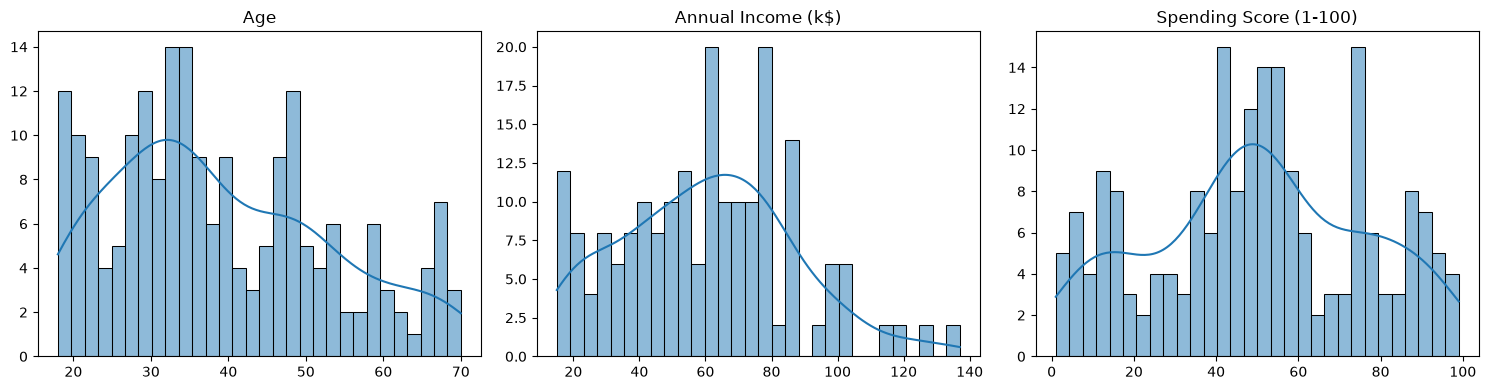

In [ ]:
import math
def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    
    n_rows = math.ceil(len(num_cols) / n_cols)
    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    
    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")  
    plt.tight_layout()
    plt.show()
plot_all_histograms(df)

In [7]:
print(df)

      Genre  Age  Annual Income (k$)  Spending Score (1-100)
0      Male   19                  15                      39
1      Male   21                  15                      81
2    Female   20                  16                       6
3    Female   23                  16                      77
4    Female   31                  17                      40
..      ...  ...                 ...                     ...
195  Female   35                 120                      79
196  Female   45                 126                      28
197    Male   32                 126                      74
198    Male   32                 137                      18
199    Male   30                 137                      83

[200 rows x 4 columns]


In [8]:
print(df["Genre"])

0        Male
1        Male
2      Female
3      Female
4      Female
        ...  
195    Female
196    Female
197      Male
198      Male
199      Male
Name: Genre, Length: 200, dtype: str


In [9]:
label_encoder = LabelEncoder()

df["Genre"] = label_encoder.fit_transform(df["Genre"])

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
print(df_scaled)

[[1.         0.01923077 0.         0.3877551 ]
 [1.         0.05769231 0.         0.81632653]
 [0.         0.03846154 0.00819672 0.05102041]
 [0.         0.09615385 0.00819672 0.7755102 ]
 [0.         0.25       0.01639344 0.39795918]
 [0.         0.07692308 0.01639344 0.76530612]
 [0.         0.32692308 0.02459016 0.05102041]
 [0.         0.09615385 0.02459016 0.94897959]
 [1.         0.88461538 0.03278689 0.02040816]
 [0.         0.23076923 0.03278689 0.7244898 ]
 [1.         0.94230769 0.03278689 0.13265306]
 [0.         0.32692308 0.03278689 1.        ]
 [0.         0.76923077 0.04098361 0.14285714]
 [0.         0.11538462 0.04098361 0.7755102 ]
 [1.         0.36538462 0.04098361 0.12244898]
 [1.         0.07692308 0.04098361 0.79591837]
 [0.         0.32692308 0.04918033 0.34693878]
 [1.         0.03846154 0.04918033 0.66326531]
 [1.         0.65384615 0.06557377 0.28571429]
 [0.         0.32692308 0.06557377 0.98979592]
 [1.         0.32692308 0.07377049 0.34693878]
 [1.         

(200, 4)


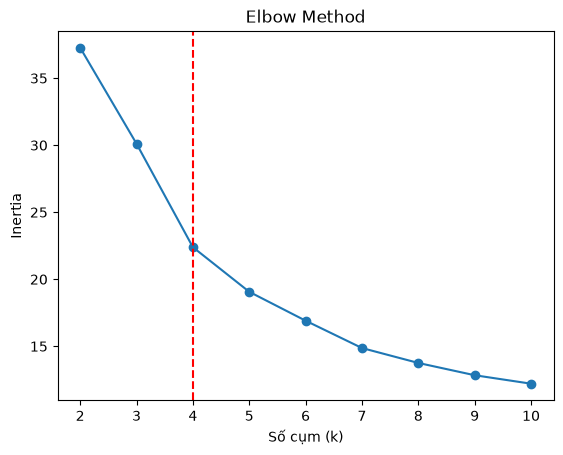

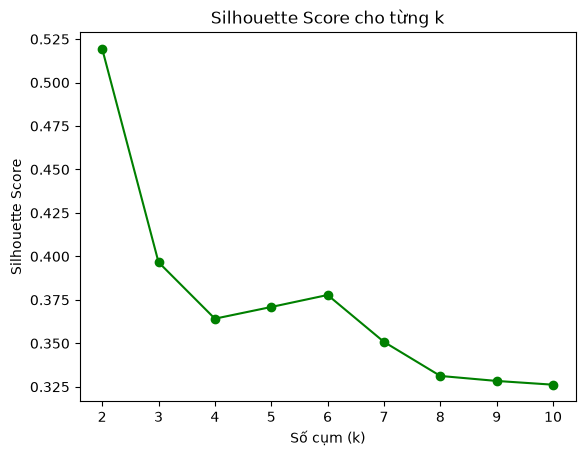

In [10]:
inertia = []
silhouette_scores = []
print(df_scaled.shape)
k_values = range(2,11)
for k in k_values:
    k_means = KMeans(k, random_state=42)
    k_means.fit(df_scaled)
    inertia.append(k_means.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, k_means.labels_))

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Số cụm (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.axvline(
    x=4,
    color="r",
    linestyle="--",
    label=f"Elbow Point (k={4})",
)
plt.show()

# Vẽ Silhouette Score
plt.plot(k_values, silhouette_scores, marker="o", color="green")
plt.xlabel("Số cụm (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score cho từng k")
plt.show()


In [11]:
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Số cluster tối ưu theo Silhouette Score: {optimal_k}")
print(f"Silhouette Score cao nhất: {max(silhouette_scores):.3f}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

silhouette_score(df_scaled, k_means.labels_)

Số cluster tối ưu theo Silhouette Score: 2
Silhouette Score cao nhất: 0.519


0.3261954593397033

In [12]:
from kneed import KneeLocator
kl = KneeLocator(k_values, inertia, curve="convex", direction="decreasing")
optimal_k = kl.elbow
print(f"Số cluster tối ưu theo Elbow Method: {optimal_k}")
print(f"Elbow Point: {max(silhouette_scores):.3f}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

Số cluster tối ưu theo Elbow Method: 5
Elbow Point: 0.519
